Epoch 1/15
7/7 [==============================] - 6s 599ms/step - loss: 1.2458 - accuracy: 0.3935 - val_loss: 1.0409 - val_accuracy: 0.3846
Epoch 2/15
7/7 [==============================] - 4s 511ms/step - loss: 1.0147 - accuracy: 0.5556 - val_loss: 0.7737 - val_accuracy: 0.7179
Epoch 3/15
7/7 [==============================] - 3s 430ms/step - loss: 0.7533 - accuracy: 0.7130 - val_loss: 0.3425 - val_accuracy: 0.9744
Epoch 4/15
7/7 [==============================] - 3s 358ms/step - loss: 0.6126 - accuracy: 0.7407 - val_loss: 0.3998 - val_accuracy: 0.7436
Epoch 5/15
7/7 [==============================] - 4s 486ms/step - loss: 0.5154 - accuracy: 0.7639 - val_loss: 0.2553 - val_accuracy: 0.9744
Epoch 6/15
7/7 [==============================] - 4s 563ms/step - loss: 0.4331 - accuracy: 0.8241 - val_loss: 0.2702 - val_accuracy: 0.9744
Epoch 7/15
7/7 [==============================] - 4s 535ms/step - loss: 0.2619 - accuracy: 0.9120 - val_loss: 0.3698 - val_accuracy: 0.8718
Epoch 8/15
7/7 [====

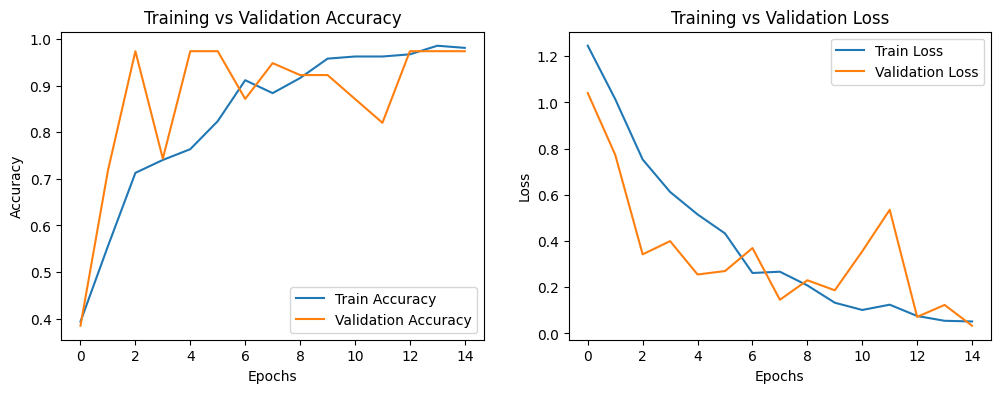

2/2 [==============================] - 0s 39ms/step
              precision    recall  f1-score   support

 transparent       1.00      0.93      0.97        15
    colorful       0.95      1.00      0.98        20
       black       1.00      1.00      1.00        10

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



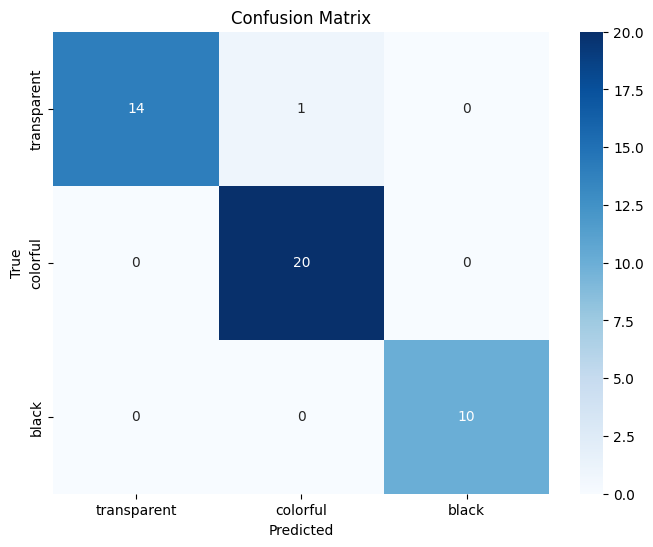

In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Parameteres defined the user ( which is Us )
img_size = 128
categories = ['transparent', 'colorful', 'black']
dataset_path = r"C:\Users\hp\Desktop\Data"  # Specify the path to your dataset

data = []

# Step 1: Load and process the images
for label, category in enumerate(categories):
    path = os.path.join(dataset_path, category)
    for img_name in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_name))
        img = cv2.resize(img, (img_size, img_size)) / 255.0
        data.append((img, label))

# Step 2: Shuffle the data and split it
np.random.shuffle(data)
X, y = zip(*data)
X, y = np.array(X), to_categorical(y, num_classes=len(categories))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15)

# Step 3: the TensorFlow model being built
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(categories), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 4: Data augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True
)
datagen.fit(X_train)

# Step 5: now we train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    epochs=15, validation_data=(X_val, y_val))

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 6: for better graphical representation, training and validation accuracy was added.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Step 7: to use the Web-Cam for real life detection
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Frame being processed
    img = cv2.resize(frame, (img_size, img_size)) / 255.0
    img = np.expand_dims(img, axis=0)

    # predictions being made
    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    class_label = categories[class_index]

    # Display prediction on the frame
    cv2.putText(frame, class_label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow("Object Classification", frame)

    # By pressing 'q" the program ends
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# Step 8: Classification report for graphical representation
# Get predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
report = classification_report(y_true, y_pred_classes, target_names=categories)
print(report)

# Step 9: Confusion matrix for graphical representation
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
import tkinter as tk
from tkinter import filedialog, Label, Button
import threading
import cv2
import numpy as np

# Function to train the model
def train_model():
    status_label.config(text="Training the model...It won't take much!")
    threading.Thread(target=run_training).start()

def run_training():
    global model, X_train, y_train, X_val, y_val, datagen
    model.fit(datagen.flow(X_train, y_train, batch_size=32),
              epochs=15, validation_data=(X_val, y_val))
    status_label.config(text="Model trained successfully!")

# Function to evaluate the model
def evaluate_model():
    status_label.config(text="Evaluating the model...")
    threading.Thread(target=run_evaluation).start()

def run_evaluation():
    global model, X_test, y_test
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    status_label.config(text=f"Test Accuracy: {test_accuracy:.2f}")

# Function for real-time webcam detection
def start_webcam():
    status_label.config(text="Starting webcam... (Make sure you're locked in.)")
    threading.Thread(target=run_webcam).start()

def run_webcam():
    global model, categories, img_size
    cap = cv2.VideoCapture(0)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Frame processing
        img = cv2.resize(frame, (img_size, img_size)) / 255.0
        img = np.expand_dims(img, axis=0)

        # Prediction
        prediction = model.predict(img)
        class_index = np.argmax(prediction)
        class_label = categories[class_index]

        # Display prediction
        cv2.putText(frame, class_label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.imshow("Object Classification", frame)

        # Exit on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    status_label.config(text="Webcam closed.")

# Initialize the Tkinter GUI
root = tk.Tk()
root.title("Object Classification GUI")
root.geometry("400x300")

Label(root, text="Object Classification", font=("Helvetica", 16)).pack(pady=10)

train_button = Button(root, text="Train Model", command=train_model, width=20)
train_button.pack(pady=5)

evaluate_button = Button(root, text="Evaluate Model", command=evaluate_model, width=20)
evaluate_button.pack(pady=5)

webcam_button = Button(root, text="Start Webcam Detection", command=start_webcam, width=20)
webcam_button.pack(pady=5)

status_label = Label(root, text="", font=("Helvetica", 12), fg="blue")
status_label.pack(pady=20)

exit_button = Button(root, text="Exit", command=root.quit, width=20)
exit_button.pack(pady=5)

root.mainloop()


1/1 [==============================] - 0s 43ms/step
Epoch 1/15
7/7 [==============================] - 4s 527ms/step - loss: 4.3804e-04 - accuracy: 1.0000 - val_loss: 0.0205 - val_accuracy: 1.0000
Epoch 2/15
7/7 [==============================] - 4s 491ms/step - loss: 2.4112e-04 - accuracy: 1.0000 - val_loss: 0.0103 - val_accuracy: 1.0000
Epoch 3/15
1/1 [==============================] - 0s 95ms/step
Epoch 4/15
7/7 [==============================] - 5s 659ms/step - loss: 1.3683e-04 - accuracy: 1.0000 - val_loss: 0.0062 - val_accuracy: 1.0000
Epoch 5/15
7/7 [==============================] - 5s 741ms/step - loss: 0.0044 - accuracy: 0.9954 - val_loss: 0.0905 - val_accuracy: 0.9744
Epoch 6/15
1/1 [==============================] - 0s 86ms/step
Epoch 7/15
1/1 [==============================] - 0s 115ms/step
Epoch 8/15
7/7 [==============================] - 5s 624ms/step - loss: 0.0013 - accuracy: 1.0000 - val_loss: 0.0068 - val_accuracy: 1.0000
Epoch 9/15
7/7 [==============================